# Lesson 0005: language as counting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tamnd/soroban/blob/main/lessons/0005-bigram/lesson.ipynb)

Four lessons fit numbers to numbers. This one reads a short list of words, counts which letter follows which, and turns the counts into a machine that writes new words. No gradient descent, no learning rate: the whole model is a table of tallies and one division, and its output is text. The full writeup is in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0005-bigram).

![sampling a word by walking the table](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0005-bigram/assets/walk.gif)

## 0. The corpus, with boundaries

Three words: cat, cot, cab. Wrap each in a [boundary token](https://github.com/tamnd/soroban/blob/main/maths/notation.md) `.`, which marks where a word starts and ends, so the model can also learn which letters begin a word and which end one. The alphabet is the six symbols that appear.

In [1]:
CORPUS = ["cat", "cot", "cab"]
ALPHABET = ['.', 'a', 'b', 'c', 'o', 't']
IDX = {c: i for i, c in enumerate(ALPHABET)}
V = len(ALPHABET)

def bigrams(word):
    s = '.' + word + '.'
    return list(zip(s, s[1:]))

print(bigrams("cat"))

[('.', 'c'), ('c', 'a'), ('a', 't'), ('t', '.')]


## 1. Count the pairs

Slide a two-symbol window across each bounded word and tally every adjacent pair. Twelve pairs in all, and the tally is the entire model.

In [2]:
import numpy as np

N = np.zeros((V, V), dtype=np.int64)
for w in CORPUS:
    for a, b in bigrams(w):
        N[IDX[a], IDX[b]] += 1

print("total bigrams:", N.sum())
assert N.sum() == 12
assert N[IDX['.'], IDX['c']] == 3          # every word starts with c
assert N[IDX['c'], IDX['a']] == 2 and N[IDX['c'], IDX['o']] == 1
assert N[IDX['a'], IDX['t']] == 1 and N[IDX['a'], IDX['b']] == 1

total bigrams: 12


## 2. Normalize each row into probabilities

Divide each count by its row total. The fraction is the model's next-letter probability, the [maximum likelihood estimate](https://github.com/tamnd/soroban/blob/main/maths/bigram.md). Every row sums to 1, the same shape a [softmax](https://github.com/tamnd/soroban/blob/main/maths/softmax.md) makes, reached by counting.

In [3]:
rows = N.sum(axis=1, keepdims=True)
P = np.divide(N, rows, out=np.zeros((V, V)), where=rows > 0)

for a in ALPHABET:
    nexts = {b: round(P[IDX[a], IDX[b]], 3) for b in ALPHABET if P[IDX[a], IDX[b]] > 0}
    print(f"{a} -> {nexts}")
assert P[IDX['c'], IDX['a']] == 2/3 and P[IDX['c'], IDX['o']] == 1/3
assert P[IDX['a'], IDX['t']] == 0.5 and P[IDX['a'], IDX['b']] == 0.5

. -> {'c': np.float64(1.0)}
a -> {'b': np.float64(0.5), 't': np.float64(0.5)}
b -> {'.': np.float64(1.0)}
c -> {'a': np.float64(0.667), 'o': np.float64(0.333)}
o -> {'t': np.float64(1.0)}
t -> {'.': np.float64(1.0)}


The whole model drawn as a heatmap: rows are the current letter, columns the next, brightness the probability. Blank means a pair never occurred.

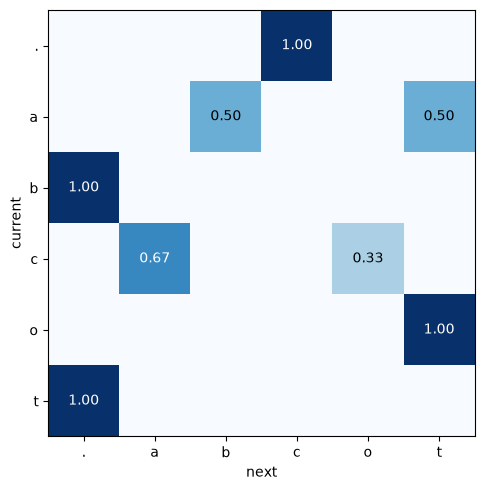

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(P, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(V)); ax.set_xticklabels(ALPHABET)
ax.set_yticks(range(V)); ax.set_yticklabels(ALPHABET)
ax.set_xlabel("next"); ax.set_ylabel("current")
for i in range(V):
    for j in range(V):
        if P[i, j] > 0:
            ax.text(j, i, f"{P[i, j]:.2f}", ha='center', va='center',
                    color='white' if P[i, j] > 0.5 else 'black')
plt.tight_layout(); plt.show()

## 3. The loss is the lesson 0003 loss

The probability of a word is the product of its bigram probabilities; each of cat, cot, cab comes out to exactly 1/3. The loss is the average `-log P` over every bigram, which is the [cross-entropy](https://github.com/tamnd/soroban/blob/main/maths/cross-entropy.md) from lesson 0003 read off a count table. It equals log(3)/4.

In [5]:
import math

def word_prob(word):
    p = 1.0
    for a, b in bigrams(word):
        p *= P[IDX[a], IDX[b]]
    return p

for w in CORPUS:
    print(f"P({w}) = {word_prob(w):.6f}")
    assert abs(word_prob(w) - 1/3) < 1e-12

loss = np.mean([-math.log(P[IDX[a], IDX[b]]) for w in CORPUS for a, b in bigrams(w)])
print("corpus loss:", round(loss, 6), " log(3)/4 =", round(math.log(3)/4, 6))
assert abs(loss - math.log(3)/4) < 1e-12

P(cat) = 0.333333
P(cot) = 0.333333
P(cab) = 0.333333
corpus loss: 0.274653  log(3)/4 = 0.274653


## 4. Sample: turn the table into a writer

Start at `.`, and at each step take a roll between 0 and 1 and walk the current row's probabilities until the running total reaches the roll. Fixed rolls make the output deterministic, so it matches numpy, torch, and Go. Asked to write, this model writes its training set back.

In [6]:
DICE = [0.5,0.2,0.8,0.5, 0.5,0.9,0.5,0.5, 0.5,0.2,0.3,0.5]

def sample(dice, n_words=3):
    it = iter(dice); words = []
    for _ in range(n_words):
        cur, out = '.', []
        while True:
            u = next(it); cum = 0.0; nxt = '.'
            for s in ALPHABET:
                cum += P[IDX[cur], IDX[s]]
                if cum >= u:
                    nxt = s; break
            if nxt == '.':
                break
            out.append(nxt); cur = nxt
        words.append(''.join(out))
    return words

print("sampled:", sample(DICE))
assert sample(DICE) == ["cat", "cot", "cab"]

sampled: ['cat', 'cot', 'cab']


## 5. Break it: a word the corpus never saw

Score dog. Its first bigram `.d` was never seen, so its probability is 0 and its loss is `-log 0`, infinity: the model calls dog impossible. Add-one smoothing pretends every possible bigram was seen once extra, so no probability is ever zero, and dog gets a small finite loss instead.

In [7]:
def word_prob_safe(word):
    p = 1.0
    for a, b in bigrams(word):
        if a not in IDX or b not in IDX:
            return 0.0
        p *= P[IDX[a], IDX[b]]
    return p

print("P(dog) =", word_prob_safe("dog"), " -> loss is infinite")
assert word_prob_safe("dog") == 0.0

def psmooth(a, b):
    c = N[IDX[a], IDX[b]] if (a in IDX and b in IDX) else 0
    row = N[IDX[a]].sum() if a in IDX else 0
    return (c + 1) / (row + V)

p_dog = 1.0
for a, b in bigrams("dog"):
    p_dog *= psmooth(a, b)
print("add-one P(dog) =", round(p_dog, 6), " loss", round(-math.log(p_dog), 6))
assert abs(p_dog - 0.00044092) < 1e-8

P(dog) = 0.0  -> loss is infinite
add-one P(dog) = 0.000441  loss 7.726654


## 6. Exit test: add cab a second time

With cat, cot, cab, cab the letter c now goes to a three times and o once, so `a|c` rises to 3/4 and `o|c` falls to 1/4. The words are no longer equally likely, and the loss drops below log(3)/4: the model got more certain and bet more on cab, the word it now sees most. That is what training always does, here done by adding one word to a tally.

In [8]:
N2 = np.zeros((V, V), dtype=np.int64)
for w in ["cat", "cot", "cab", "cab"]:
    for a, b in bigrams(w):
        N2[IDX[a], IDX[b]] += 1
P2 = np.divide(N2, N2.sum(1, keepdims=True), out=np.zeros((V, V)), where=N2.sum(1, keepdims=True) > 0)
loss2 = np.mean([-math.log(P2[IDX[a], IDX[b]]) for w in ["cat","cot","cab","cab"] for a, b in bigrams(w)])
print("a|c", P2[IDX['c'], IDX['a']], " o|c", P2[IDX['c'], IDX['o']], " loss", round(loss2, 6))
assert P2[IDX['c'], IDX['a']] == 0.75 and P2[IDX['c'], IDX['o']] == 0.25
assert abs(loss2 - 0.259930) < 1e-6 and loss2 < math.log(3)/4

a|c 0.75  o|c 0.25  loss 0.25993


## 7. Torch agrees

The count matrix is a tensor and the loss is a gather-and-log, the same arithmetic in a different tool.

In [9]:
try:
    import torch

    Nt = torch.zeros((V, V), dtype=torch.float64)
    for w in CORPUS:
        for a, b in bigrams(w):
            Nt[IDX[a], IDX[b]] += 1
    Pt = Nt / Nt.sum(1, keepdim=True).clamp(min=1)
    prev = torch.tensor([IDX[a] for w in CORPUS for a, _ in bigrams(w)])
    nxt = torch.tensor([IDX[b] for w in CORPUS for _, b in bigrams(w)])
    tloss = (-Pt[prev, nxt].log()).mean().item()
    print("torch loss:", round(tloss, 6))
    assert abs(tloss - math.log(3)/4) < 1e-12
    print("torch agrees with the counting model")
except ImportError:
    print("torch not installed, skipping (Colab has it preinstalled)")

torch loss: 0.274653
torch agrees with the counting model


## Exercises

1. You just ran the exit test: cat, cot, cab, cab drops the loss to 0.259930. Predict, before editing, what cat, cat, cot, cab does to `a|c` and to the loss, then check it.
2. What single change to the corpus would make the model sample cab twice as often as cat? Sampling frequency follows the probabilities, and the probabilities follow the counts.
3. Score `at` (no leading c). Its first bigram is `.a`. Is that probability zero, and what does the answer say about which words this model thinks are possible?

Worked answers are in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0005-bigram) and asserted in `train.py`. Lesson 0006 replaces the counting with a single-layer network trained by the lesson 0004 engine, and its weights converge to this very table.